# Soybean (Small) — Dataset Analysis Notebook

This notebook loads and explores the **Soybean (Small)** dataset from the UCI Machine Learning Repository and builds a few baseline models.

**Dataset**
- Instances: 47  
- Features: 35 (categorical, encoded as integers)  
- Target: 4 disease classes (`D1`–`D4`)

Source (data file): `soybean-small.data`


In [ ]:
# If needed, install dependencies (usually already available)
# !pip install -q pandas numpy matplotlib scikit-learn requests nbformat

In [1]:
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

## 1) Load the dataset

In [2]:
DATA_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/soybean/soybean-small.data"

# Column names from the UCI dataset page (35 features) + class label
feature_names = [
    "date","plant-stand","precip","temp","hail","crop-hist","area-damaged","severity",
    "seed-tmt","germination","plant-growth","leaves","leafspots-halo","leafspots-marg",
    "leafspot-size","leaf-shread","leaf-malf","leaf-mild","stem","lodging",
    "stem-cankers","canker-lesion","fruiting-bodies","external decay","mycelium",
    "int-discolor","sclerotia","fruit-pods","fruit spots","seed","mold-growth",
    "seed-discolor","seed-size","shriveling","roots"
]
cols = feature_names + ["class"]

raw = requests.get(DATA_URL, timeout=30)
raw.raise_for_status()

text = raw.text.strip()

# The file is space-separated rows, each row is comma-separated values
rows = text.split()
data = [r.split(",") for r in rows]

df = pd.DataFrame(data, columns=cols)

# Convert feature columns to integers (categorical codes)
for c in feature_names:
    df[c] = df[c].astype(int)

df["class"] = df["class"].astype("category")

df.shape, df["class"].cat.categories.tolist()

((47, 36), ['D1', 'D2', 'D3', 'D4'])

In [3]:
df.head()

,date,plant-stand,precip,temp,hail,crop-hist,area-damaged,severity,seed-tmt,germination,...,sclerotia,fruit-pods,fruit spots,seed,mold-growth,seed-discolor,seed-size,shriveling,roots,class
0,4,0,2,1,1,1,0,1,0,2,...,0,0,4,0,0,0,0,0,0,D1
1,5,0,2,1,0,3,1,1,1,2,...,0,0,4,0,0,0,0,0,0,D1
2,3,0,2,1,0,2,0,2,1,1,...,0,0,4,0,0,0,0,0,0,D1
3,6,0,2,1,0,1,1,1,0,0,...,0,0,4,0,0,0,0,0,0,D1
4,4,0,2,1,0,3,0,2,0,2,...,0,0,4,0,0,0,0,0,0,D1


## 2) Quick EDA

In [4]:
df.describe(include="all").T.head(12)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
date,47.0,NaN,NaN,NaN,2.702128,2.04211,0.0,1.0,3.0,4.0,6.0
plant-stand,47.0,NaN,NaN,NaN,0.531915,0.504375,0.0,0.0,1.0,1.0,1.0
precip,47.0,NaN,NaN,NaN,1.489362,0.830724,0.0,1.0,2.0,2.0,2.0
temp,47.0,NaN,NaN,NaN,0.765957,0.666358,0.0,0.0,1.0,1.0,2.0
hail,47.0,NaN,NaN,NaN,0.319149,0.471186,0.0,0.0,0.0,1.0,1.0
crop-hist,47.0,NaN,NaN,NaN,1.723404,1.077479,0.0,1.0,2.0,3.0,3.0
area-damaged,47.0,NaN,NaN,NaN,1.212766,0.858111,0.0,1.0,1.0,1.0,3.0
severity,47.0,NaN,NaN,NaN,1.404255,0.496053,1.0,1.0,1.0,2.0,2.0
seed-tmt,47.0,NaN,NaN,NaN,0.489362,0.505291,0.0,0.0,0.0,1.0,1.0
germination,47.0,NaN,NaN,NaN,1.12766,0.824015,0.0,0.0,1.0,2.0,2.0


In [5]:
class_counts = df["class"].value_counts().sort_index()
class_counts

class
D1    10
D2    10
D3    10
D4    17
Name: count, dtype: int64

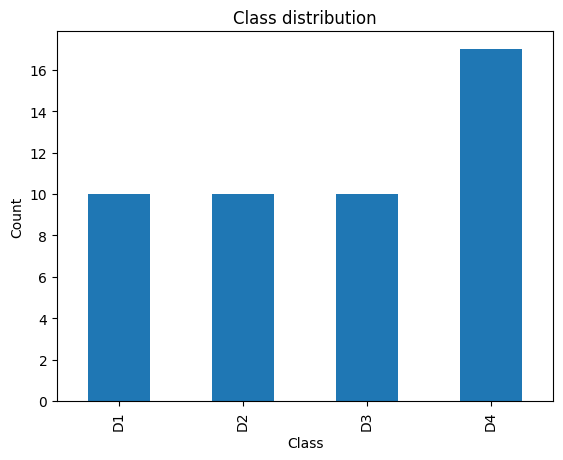

In [6]:
plt.figure()
class_counts.plot(kind="bar")
plt.title("Class distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

## 3) Prepare features and target

The features are **categorical codes** (integers). We'll one-hot encode them before training models.

In [ ]:
X = df[feature_names].copy()
y = df["class"].copy()

# One-hot encode all 35 categorical features
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), feature_names)
    ],
    remainder="drop"
)


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

ColumnTransformer(transformers=[('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['date', 'plant-stand', 'precip', 'temp',
                                  'hail', 'crop-hist', 'area-damaged',
                                  'severity', 'seed-tmt', 'germination',
                                  'plant-growth', 'leaves', 'leafspots-halo',
                                  'leafspots-marg', 'leafspot-size',
                                  'leaf-shread', 'leaf-malf', 'leaf-mild',
                                  'stem', 'lodging', 'stem-cankers',
                                  'canker-lesion', 'fruiting-bodies',
                                  'external decay', 'mycelium', 'int-discolor',
                                  'sclerotia', 'fruit-pods', 'fruit spots',
                                  'seed', ...])])


## 4) Baseline and model comparison (cross-validation)

In [ ]:
models = {
    "Dummy (most_frequent)": DummyClassifier(strategy="most_frequent"),
    "LogReg": LogisticRegression(max_iter=2000),
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=300, random_state=42),
}

scoring = {"acc": "accuracy", "f1_macro": "f1_macro"}

results = []
for name, clf in models.items():
    pipe = Pipeline([("prep", preprocess), ("clf", clf)])
    scores = cross_validate(pipe, X, y, cv=cv, scoring=scoring, n_jobs=None, return_train_score=False)
    results.append({
        "model": name,
        "accuracy_mean": scores["test_acc"].mean(),
        "accuracy_std": scores["test_acc"].std(),
        "f1_macro_mean": scores["test_f1_macro"].mean(),
        "f1_macro_std": scores["test_f1_macro"].std(),
    })

pd.DataFrame(results).sort_values("f1_macro_mean", ascending=False)

## 5) Confusion matrix for a strong baseline (RandomForest)

In [ ]:
best_model = Pipeline([
    ("prep", preprocess),
    ("clf", RandomForestClassifier(n_estimators=300, random_state=42))
])

y_pred = cross_val_predict(best_model, X, y, cv=cv)

print(classification_report(y, y_pred))

disp = ConfusionMatrixDisplay.from_predictions(y, y_pred)
plt.title("Confusion matrix (5-fold CV predictions)")
plt.show()

## 6) Optional: 2D visualization (PCA on one-hot features)

In [ ]:
from sklearn.decomposition import PCA

X_oh = preprocess.fit_transform(X)  # sparse matrix
X_oh_dense = X_oh.toarray() if hasattr(X_oh, "toarray") else np.asarray(X_oh)

pca = PCA(n_components=2, random_state=42)
X2 = pca.fit_transform(X_oh_dense)

plt.figure()
for cls in y.cat.categories:
    mask = (y == cls).to_numpy()
    plt.scatter(X2[mask, 0], X2[mask, 1], label=str(cls))

plt.title("PCA (2D) of one-hot encoded features")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()

## Next ideas

- Hyperparameter tuning (GridSearchCV) for RandomForest / Tree depth.
- Try Naive Bayes for categorical features (after encoding).
- Feature importance analysis from tree-based models.
- Clustering the one-hot space and evaluating with external metrics (ARI/NMI) using `class` as ground truth.
